## Model selection brain score

Imports

In [36]:
import pickle
import warnings
import os

import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats
from sklearn.model_selection import ShuffleSplit
from pathlib import Path
import logging
import sys
sys.path.insert(1, '../')

from unfold import unfold_model, unfold_utils

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Configure the logger
logging.basicConfig(
    level=logging.DEBUG,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

Define picks

In [47]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG data

In [48]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform unfolding with CV

In [49]:
class UnfoldModelPy:
    def __init__(self, u_model):
        self.u_model = u_model
        self.channels = None
        self.cv_results = {}
        self.channel_results = {}
        self.model = None
        self.num_parameters = None

    def fit_unfold_model(
            self,
            raw,
            events_df,
            cv=ShuffleSplit(n_splits=20, random_state=42, test_size=0.50),
            channels='all',
            as_epochs=True,
            refit=False
    ):
        # perform unfolding separately for each channel
        if channels == 'all':
            self.channels = raw.info['ch_names']
        else:
            self.channels = channels

        for channel in self.channels:
            channel_events_df = events_df[channel]
            # clear bad segments
            channel_events_df = channel_events_df[channel_events_df['bad'] == False]
            # get EEG data
            eeg_data = raw.get_data(picks=channel)
            # cast EEG data from V to uV
            eeg_data = eeg_data * 1000000

            self.fit_channel(channel, eeg_data, channel_events_df, cv=cv, as_epochs=as_epochs, refit=refit)

        if self.channel_results:
            logger.debug(f"In saving channel results into ResultsContainer")
            results_obj = unfold_utils.ResultsContainer()
            results_obj.num_parameters = self.num_parameters
            results_obj.process_results(self.channel_results)
            self.model = results_obj

    def fit_channel(
            self,
            channel_name,
            eeg_data,
            events_df,
            cv=ShuffleSplit(n_splits=20, random_state=42, test_size=0.50),
            as_epochs=True,
            refit=False,
    ):
        if cv is not None:
            cv_predicted_train = []
            cv_original_train = []
            cv_predicted_test = []
            cv_original_test = []
            split_num = []

            # prepare data for splitting - divide events-df and raw signal into trials
            data_df = unfold_model.prepare_data_CV(eeg_data, events_df, start_tp=-13, stop_tp=101)

            # generate splits and perform unfold
            for i, (train_index, test_index) in enumerate(cv.split(data_df)):
                split_num.append(i)
                logger.debug(f"Estimating fold: {i}")
                logger.info(f"Train indices: {train_index}")
                logger.info(f"Test indices: {test_index}")

                # create data for split
                epochs_train = np.vstack(data_df['eeg_signal'].to_numpy()[train_index])
                length = epochs_train[0].shape[-1]
                logger.debug(f"Length of the epoch: {length}")
                continuous_train = np.vstack(epochs_train).flatten().reshape(1,-1)
                logger.debug(f"Continuous train shape: {continuous_train.shape}")
                channel_events_train_df = unfold_model.create_events_cv(data_df['event_df'], train_index, length)

                epochs_test = np.vstack(data_df['eeg_signal'].to_numpy()[test_index])
                continuous_test = np.vstack(epochs_test).flatten().reshape(1,-1)
                logger.debug(f"Continuous test shape: {continuous_test.shape}")
                channel_events_test_df = unfold_model.create_events_cv(data_df['event_df'], test_index, length)

                # perform unfold with train/test
                _, _, predicted_raw_train, predicted_raw_test = unfold_model.perform_unfold_cv(
                    channel_events_train_df,
                    continuous_train,
                    channel_events_test_df,
                    continuous_test,
                    self.u_model
                )

                if as_epochs:
                    cv_predicted_train.append(np.array(unfold_model.epochs_from_raw(predicted_raw_train, channel_events_train_df)))
                    cv_predicted_test.append(np.array(unfold_model.epochs_from_raw(predicted_raw_test, channel_events_test_df)))
                    cv_original_train.append(np.array(epochs_train))
                    cv_original_test.append(np.array(epochs_test))
                else:
                    cv_predicted_train.append(np.array(predicted_raw_train))
                    cv_predicted_test.append(np.array(predicted_raw_test))
                    cv_original_train.append(np.array(continuous_train))
                    cv_original_test.append(np.array(continuous_test))

            results_df = pd.DataFrame({
                'split_num': split_num,
                'train_original': cv_original_train,
                'train_predicted': cv_predicted_train,
                'test_original': cv_original_test,
                'test_predicted': cv_predicted_test,
            })

            self.cv_results[channel_name] = results_df

            if refit:
                results_channel_df, num_parameters = unfold_model.perform_unfold(
                    events_df,
                    eeg_data,
                    self.u_model
                )
                self.channel_results[channel_name] = results_channel_df
                self.num_parameters = num_parameters

        else:
            results_channel_df, num_parameters, _, _ = unfold_model.perform_unfold(
                events_df,
                eeg_data,
                self.u_model
            )
            self.channel_results[channel_name] = results_channel_df
            self.num_parameters = num_parameters

    def save_main_model(self, path):
        self.model.store_results(path)

    def save_cv_results(self, path):
        with open(f'{path}_cv.pickle', 'wb') as handle:
            pickle.dump(self.cv_results, handle, protocol=pickle.HIGHEST_PROTOCOL)

Define models to be tested

In [50]:
unfold_models = {
    'baseline': unfold_model.get_baseline_model(),
    'go': unfold_model.get_go_model(),
    'stop': unfold_model.get_stop_model(),
    'response': unfold_model.get_full_model(),
    'full_stop_type': unfold_model.get_full_stop_type_model(),
    'full_stop_type_ssd': unfold_model.get_full_stop_type_ssd_model(),
    'full_stop_type_sri': unfold_model.get_full_stop_type_sri_model(),
    'full_interactions': unfold_model.get_full_interaction_model()
}

Create dirs for outputs

In [51]:
results_main_path = '../data/cv'

for key in unfold_models.keys():
    path = Path(f"{results_main_path}/{key}")
    path.mkdir(parents=True, exist_ok=True)

In [52]:
file_names = file_names[:6]
file_names

['AB0407_SST14_EOG4',
 'AB2407_SST14_new_EOG4',
 'AD1406_SST14_EOG4',
 'AF0905_SST14_EOG4',
 'AK0102_SST14_EOG4',
 'AR1607_SST14_EOG4']

In [ ]:
cv=ShuffleSplit(n_splits=100, random_state=42, test_size=0.50)

for file_name in file_names:
    # read events dict
    with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
        events = pickle.load(handle) # events dict channel_name:events_df

    # read EEG
    raw = mne.io.read_raw_brainvision(
        f'{eeg_data_dir}/{file_name}.vhdr', 
        preload=True, 
        eog=('HEOG', 'VEOG'),
    ).pick(picks=picks)
    
    for unfold_model_name, current_unfold_model in unfold_models.items():
        unfold = UnfoldModelPy(u_model = current_unfold_model)
        unfold.fit_unfold_model(raw, events, cv=cv, as_epochs=True, refit=False, channels=['Cz', 'Fz'])
        
        # unfold.save_main_model(f"{results_main_path}/{unfold_model_name}/{file_name}")
        unfold.save_cv_results(f"{results_main_path}/{unfold_model_name}/{file_name}")

## Brain score

In [65]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

In [66]:
def calculate_brain_score(
        cv_results, 
        test=True, 
        crop=(0,0.5), 
        sfreq=64, 
        epoch_lim = (-0.2, 1.58)
):
    if test:
        variable = 'test'
    else:
        variable = 'train'
    
    person_results = {}
    for channel in cv_results.keys():
        test_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
        test_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()
        
        # epochs: -0.2 to 1.58 ms -> 0 to 114
        if crop is None:
            t_min, t_max = epoch_lim
        else:
            t_min, t_max = crop
        
        # calculate time window in timepoints
        t_min_tp = int((t_min - epoch_lim[0])*sfreq)
        t_max_tp = int((t_max - epoch_lim[0])*sfreq)
        
        # iterate over cv repeats
        cv_pearsons_r = []
        for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
            original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
            predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]
        
            original_cropped_flatten = original_cropped.flatten()
            predicted_cropped_flatten = predicted_cropped.flatten()
            
            # calculate pearsons r
            r = np.corrcoef(original_cropped_flatten, predicted_cropped_flatten)[0, 1]
            cv_pearsons_r.append(r)

        cv_pearsons_r = np.array(cv_pearsons_r)
        r_mean = cv_pearsons_r.mean()
        r_sd = cv_pearsons_r.std()

        person_results[channel] = {'cv_pearsons_r': cv_pearsons_r, 'cv_mean': r_mean, 'cv_std': r_sd}
    
    return person_results

Read stored data

In [67]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


#### Test

In [124]:
file_names = file_names[:6]
results_main_path = '../data/cv'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                  'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results, 
                test=True,
                crop=(.7, 1.5)
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

Plot results - per person

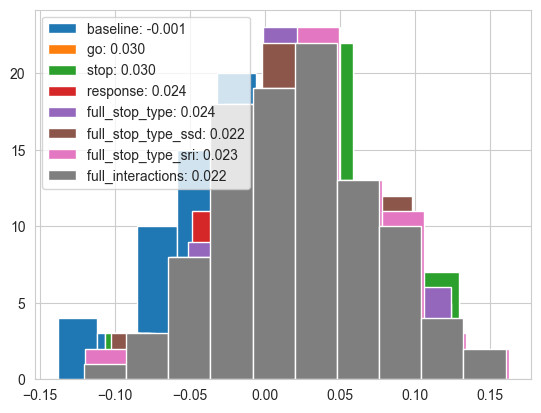

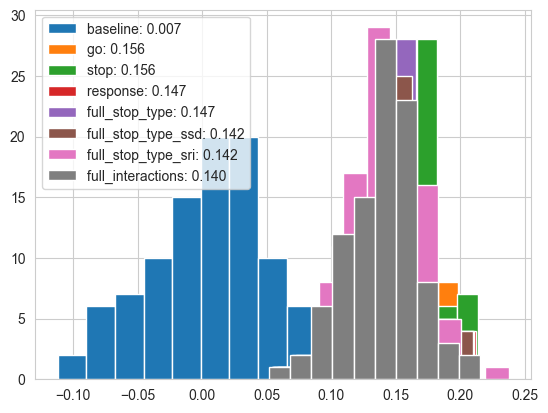

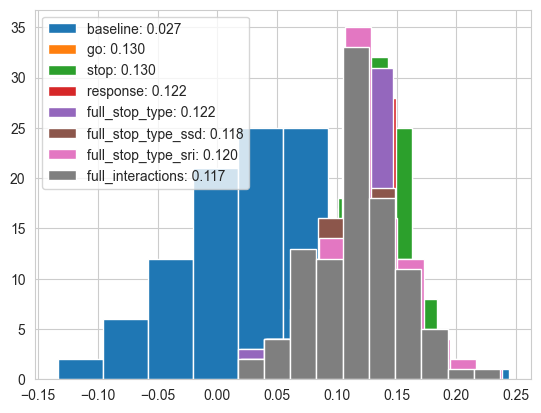

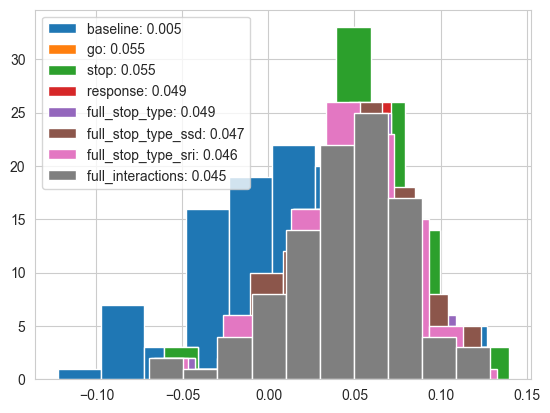

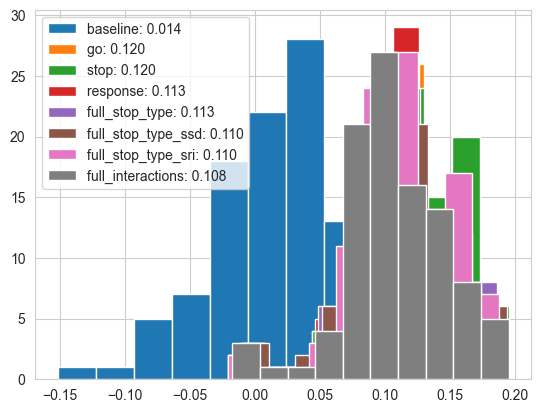

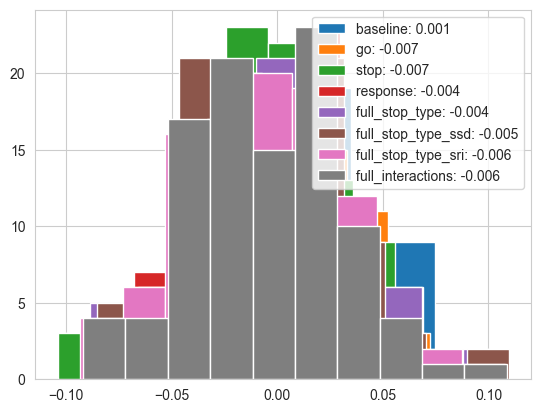

In [125]:
channel = 'Cz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.3f}")
        
    plt.legend()

Stats

In [126]:
# Paired t-tests for each person
channel = 'Cz'
paired_ttest_results = {}

for i, person_results in enumerate(models_results_aggregation):
    for model1 in unfold_models:
        for model2 in unfold_models:
            if model1 != model2:  # Avoid self-comparison
                data1 = person_results[model1][channel]['cv_pearsons_r']
                data2 = person_results[model2][channel]['cv_pearsons_r']

                # Perform paired t-test
                t_stat, p_value = stats.ttest_rel(data1, data2)

                # Store or print results
                paired_ttest_results[(file_names[i], model1, model2)] = (data1.mean(),  data2.mean(), p_value)

/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_17802/41712130.py:13: DeprecationWarning: Please import `ttest_rel` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat, p_value = stats.ttest_rel(data1, data2)


In [127]:
paired_ttest_results

{('AB0407_SST14_EOG4', 'baseline', 'go'): (-0.0005272425071898671,
  0.029885825232067592,
  1.8085873700708668e-28),
 ('AB0407_SST14_EOG4', 'baseline', 'stop'): (-0.0005272425071898671,
  0.02988601285778352,
  1.809137039495979e-28),
 ('AB0407_SST14_EOG4', 'baseline', 'response'): (-0.0005272425071898671,
  0.024044281798192842,
  1.0977370724166931e-11),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type'): (-0.0005272425071898671,
  0.02410387624675668,
  9.533660900943154e-12),
 ('AB0407_SST14_EOG4',
  'baseline',
  'full_stop_type_ssd'): (-0.0005272425071898671, 0.022243449610779994, 8.349187968300686e-10),
 ('AB0407_SST14_EOG4',
  'baseline',
  'full_stop_type_sri'): (-0.0005272425071898671, 0.022747537255851512, 1.0548284212906943e-08),
 ('AB0407_SST14_EOG4',
  'baseline',
  'full_interactions'): (-0.0005272425071898671, 0.021951346303600704, 6.282191910091898e-08),
 ('AB0407_SST14_EOG4', 'go', 'baseline'): (0.029885825232067592,
  -0.0005272425071898671,
  1.8085873700708668e-

Plot results - within people aggregations

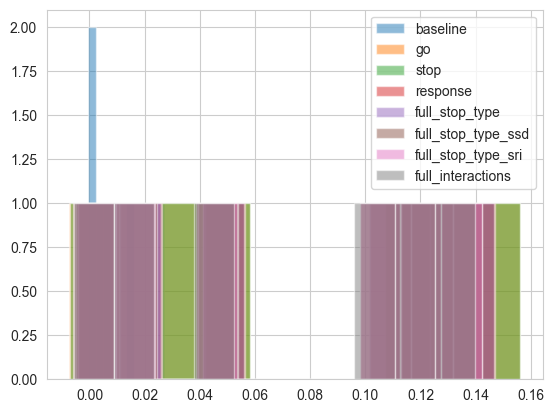

In [128]:
channel = 'Cz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()

#### Train

In [119]:
file_names = file_names[:6]
results_main_path = '../data/cv'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=False,
                crop=None
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

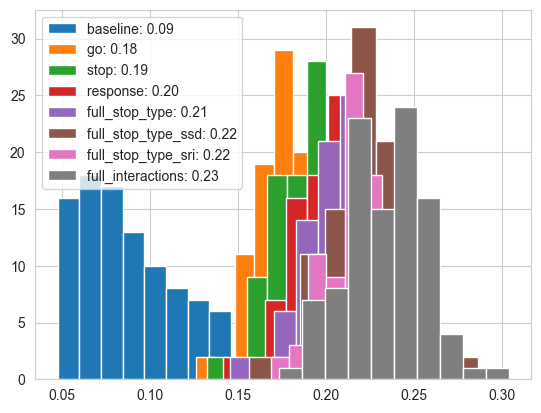

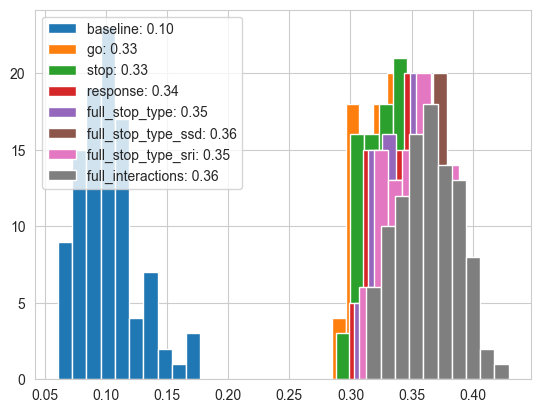

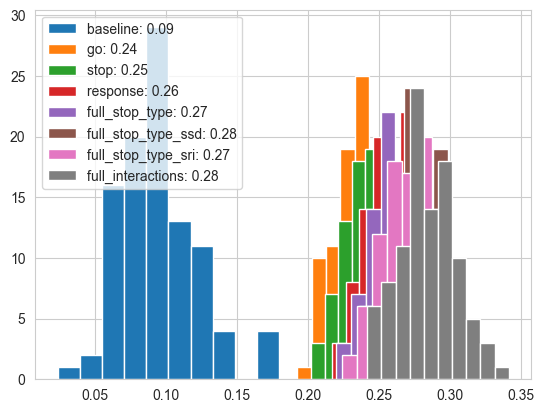

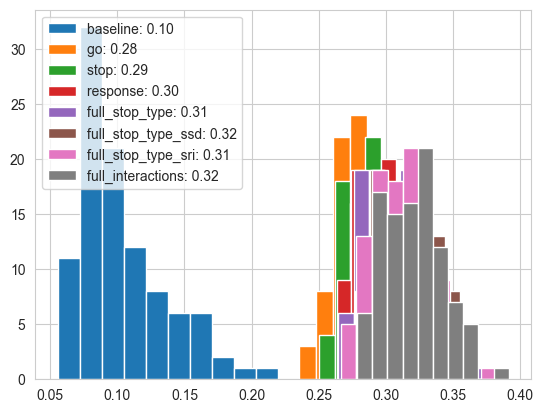

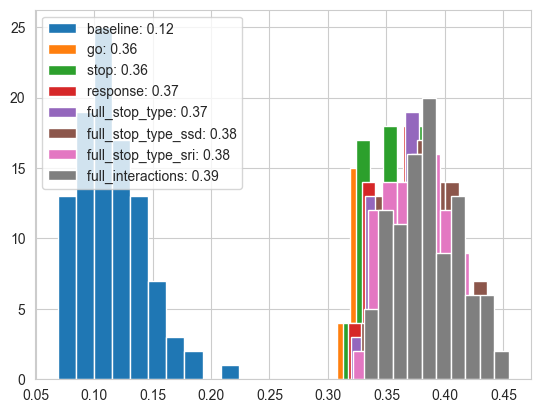

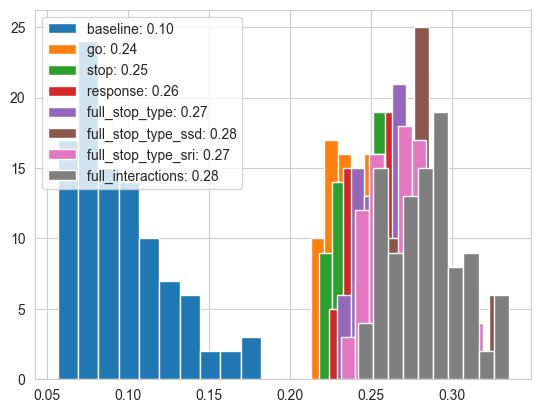

In [120]:
channel = 'Cz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.2f}")


    plt.legend()

Stats

In [121]:
# Paired t-tests for each person
channel = 'Cz'
paired_ttest_results = {}

for i, person_results in enumerate(models_results_aggregation):
    for model1 in unfold_models:
        for model2 in unfold_models:
            if model1 != model2:  # Avoid self-comparison
                data1 = person_results[model1][channel]['cv_pearsons_r']
                data2 = person_results[model2][channel]['cv_pearsons_r']

                # Perform paired t-test
                t_stat, p_value = stats.ttest_rel(data1, data2)

                # Store or print results
                paired_ttest_results[(file_names[i], model1, model2)] = (data1.mean(),  data2.mean(), p_value)

/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_17802/41712130.py:13: DeprecationWarning: Please import `ttest_rel` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat, p_value = stats.ttest_rel(data1, data2)


In [122]:
paired_ttest_results

{('AB0407_SST14_EOG4', 'baseline', 'go'): (0.09082207558733504,
  0.17866224371152967,
  3.175924212376584e-70),
 ('AB0407_SST14_EOG4', 'baseline', 'stop'): (0.09082207558733504,
  0.1899914434643397,
  5.959019916660386e-70),
 ('AB0407_SST14_EOG4', 'baseline', 'response'): (0.09082207558733504,
  0.20389320139347927,
  2.5623342933922372e-71),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type'): (0.09082207558733504,
  0.21131874302724485,
  1.813675591180763e-71),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type_ssd'): (0.09082207558733504,
  0.22381037781655555,
  1.8856030721865894e-70),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type_sri'): (0.09082207558733504,
  0.2220263616726587,
  6.780930724278205e-72),
 ('AB0407_SST14_EOG4', 'baseline', 'full_interactions'): (0.09082207558733504,
  0.23366835192331614,
  5.912430136221286e-72),
 ('AB0407_SST14_EOG4', 'go', 'baseline'): (0.17866224371152967,
  0.09082207558733504,
  3.175924212376584e-70),
 ('AB0407_SST14_EOG4', 'go', 

Plot results - within people aggregations

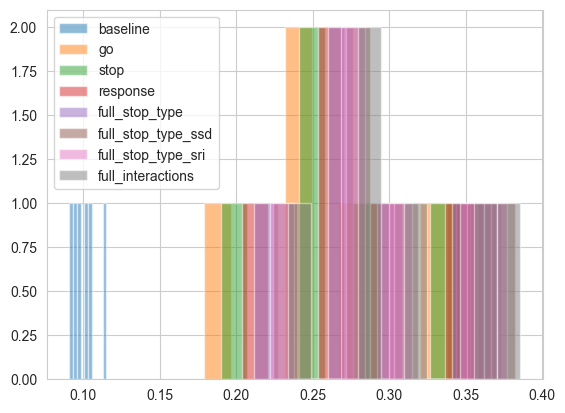

In [123]:
channel = 'Cz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()

Stats

/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_17802/984021803.py:13: DeprecationWarning: Please import `ttest_rel` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stat, p_value = stats.ttest_rel(data1, data2)


{('AB0407_SST14_EOG4', 'baseline', 'go'): (-32.19163432671506,
  1.2678784117869812e-34),
 ('AB0407_SST14_EOG4', 'baseline', 'stop'): (-23.836199946491345,
  1.3087014799506586e-28),
 ('AB0407_SST14_EOG4', 'baseline', 'response'): (-22.561214051566402,
  1.5519384388348199e-27),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type'): (-19.315731267786386,
  1.470623581666881e-24),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type_ssd'): (-17.87180888943503,
  4.16149947438944e-23),
 ('AB0407_SST14_EOG4', 'baseline', 'full_stop_type_sri'): (-18.779309318333976,
  4.9762860953120136e-24),
 ('AB0407_SST14_EOG4', 'baseline', 'full_interactions'): (-17.332507010381562,
  1.5274589380825807e-22),
 ('AB0407_SST14_EOG4', 'go', 'baseline'): (32.19163432671506,
  1.2678784117869812e-34),
 ('AB0407_SST14_EOG4', 'go', 'stop'): (3.863895375201446,
  0.0003280801618197641),
 ('AB0407_SST14_EOG4', 'go', 'response'): (6.239392450594132,
  9.996496700155609e-08),
 ('AB0407_SST14_EOG4', 'go', 'full_stop_

In [32]:
r_res_baseline = calculate_brain_score(cv_results_baseline)
print(r_res_baseline)

r_res_no_ssd = calculate_brain_score(cv_results_no_ssd)
print(r_res_no_ssd)

r_res_no_sri = calculate_brain_score(cv_results_no_sri)
print(r_res_no_sri)

r_res_full = calculate_brain_score(cv_results_full)
print(r_res_full)

{'Cz': {'cv_pearsons_r': array([-0.04840226, -0.04905089, -0.02657672,  0.00657161,  0.02098678,
       -0.05417366, -0.00490308,  0.05196871, -0.05773951, -0.00882434,
        0.07772931, -0.04385806,  0.00797111, -0.03535699,  0.11646867,
       -0.00515898, -0.02330221, -0.0850157 ,  0.01769579,  0.09477434]), ',cv_mean': -0.0024098044853923138, 'cv_std': 0.05235954845067652}}
{'Cz': {'cv_pearsons_r': array([0.13328168, 0.07310495, 0.17409954, 0.08904348, 0.23548435,
       0.1151589 , 0.16102728, 0.11995937, 0.12794948, 0.13415152,
       0.22659015, 0.10459936, 0.12965684, 0.14540371, 0.17211327,
       0.15332659, 0.10037319, 0.1295693 , 0.13126965, 0.13888608]), ',cv_mean': 0.13975243364220932, 'cv_std': 0.03929909731874302}}
{'Cz': {'cv_pearsons_r': array([0.11439925, 0.07613367, 0.11775748, 0.09893482, 0.24969342,
       0.11588965, 0.14735758, 0.11376223, 0.13265863, 0.15277083,
       0.21025816, 0.07099428, 0.12484941, 0.14580785, 0.16374231,
       0.1438639 , 0.11444508, 

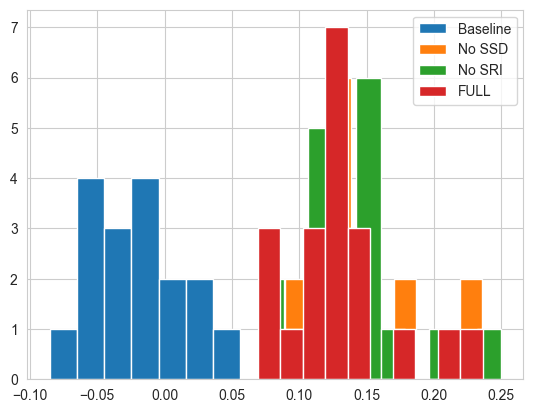

In [33]:
plt.hist(r_res_baseline['Cz']['cv_pearsons_r'], label='Baseline')
plt.hist(r_res_no_ssd['Cz']['cv_pearsons_r'], label='No SSD')
plt.hist(r_res_no_sri['Cz']['cv_pearsons_r'], label='No SRI')
plt.hist(r_res_full['Cz']['cv_pearsons_r'], label='FULL')

plt.legend()

6
44
(99, 38)
(99, 38)
(3762,)
(3762,)
0.13114111996559852
(99, 38)
(99, 38)
(3762,)
(3762,)
0.05534795474200934
(99, 38)
(99, 38)
(3762,)
(3762,)
0.16609533111977715
(99, 38)
(99, 38)
(3762,)
(3762,)
0.0824473438973446
(99, 38)
(99, 38)
(3762,)
(3762,)
0.2208028579390187
(99, 38)
(99, 38)
(3762,)
(3762,)
0.10904710328298833
(99, 38)
(99, 38)
(3762,)
(3762,)
0.15214574094008118
(99, 38)
(99, 38)
(3762,)
(3762,)
0.10387964784946242
(99, 38)
(99, 38)
(3762,)
(3762,)
0.11446143911561876
(99, 38)
(99, 38)
(3762,)
(3762,)
0.11674418535085906
(99, 38)
(99, 38)
(3762,)
(3762,)
0.20537213902860524
(99, 38)
(99, 38)
(3762,)
(3762,)
0.09283937279339603
(99, 38)
(99, 38)
(3762,)
(3762,)
0.11940257195555425
(99, 38)
(99, 38)
(3762,)
(3762,)
0.13193814000411327
(99, 38)
(99, 38)
(3762,)
(3762,)
0.1520291915980893
(99, 38)
(99, 38)
(3762,)
(3762,)
0.13988469879588167
(99, 38)
(99, 38)
(3762,)
(3762,)
0.09208922670914452
(99, 38)
(99, 38)
(3762,)
(3762,)
0.12084712872996813
(99, 38)
(99, 38)
(3762,)


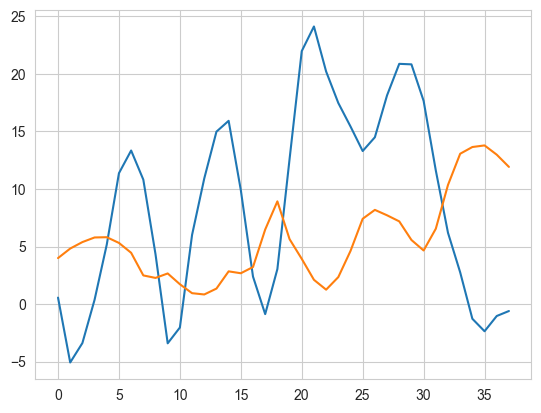

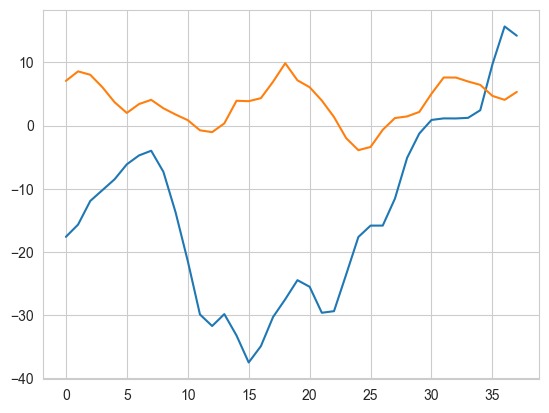

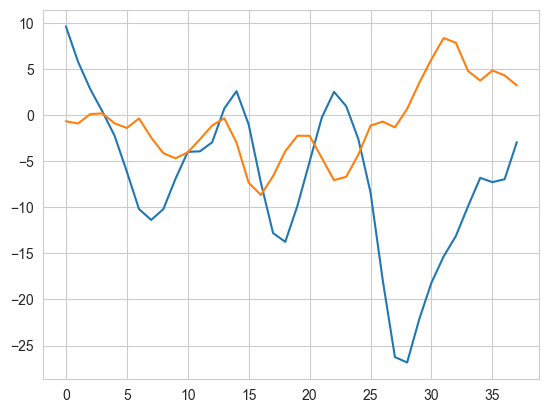

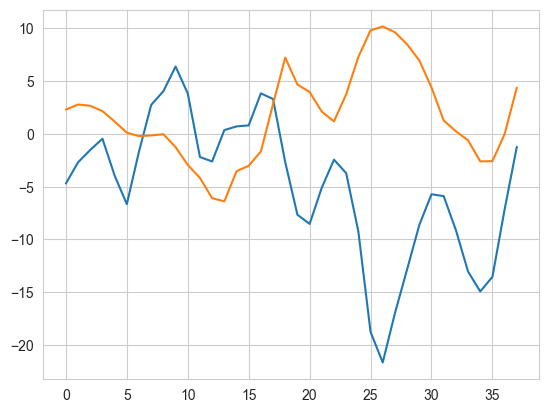

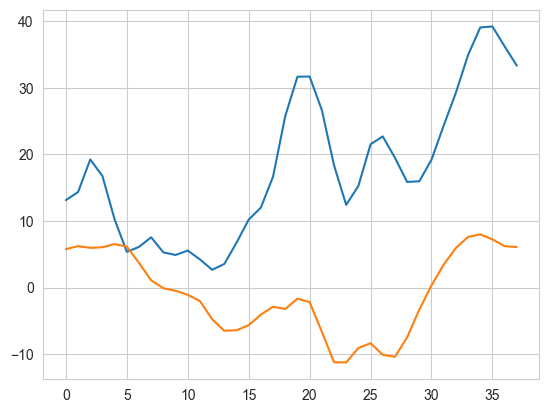

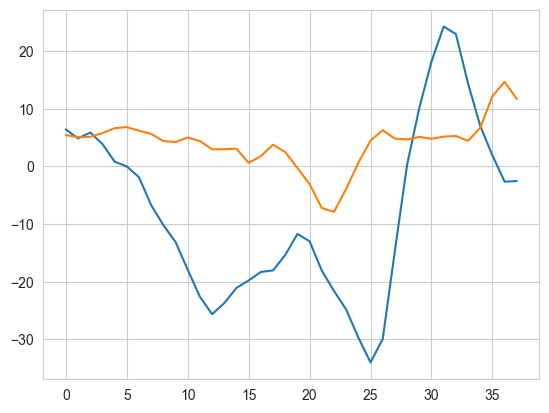

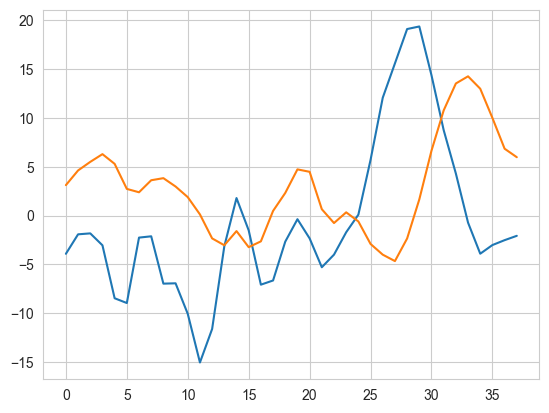

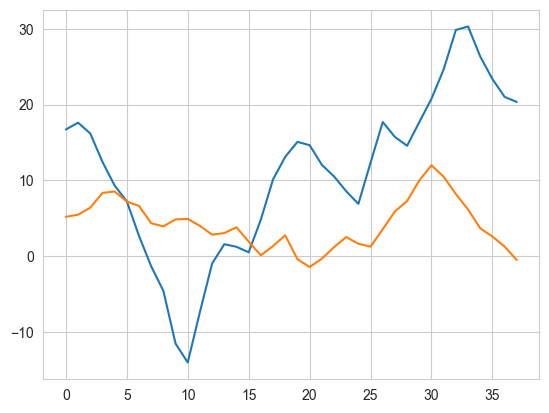

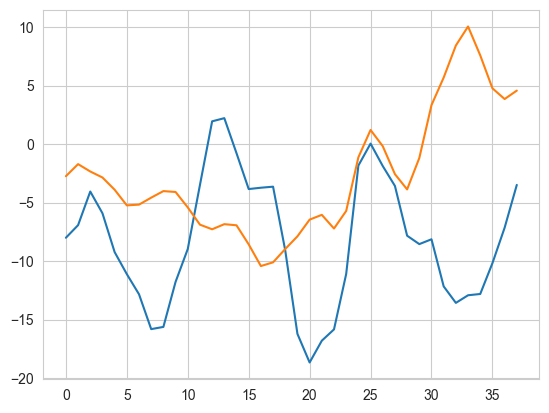

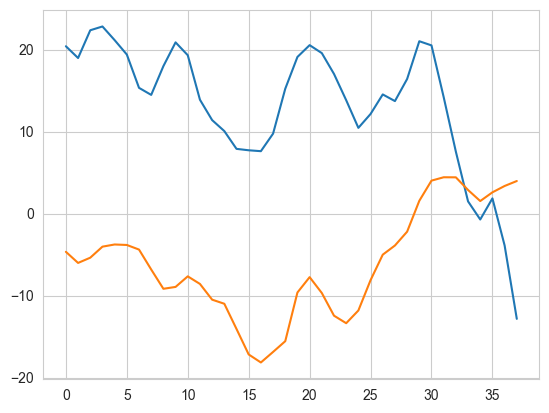

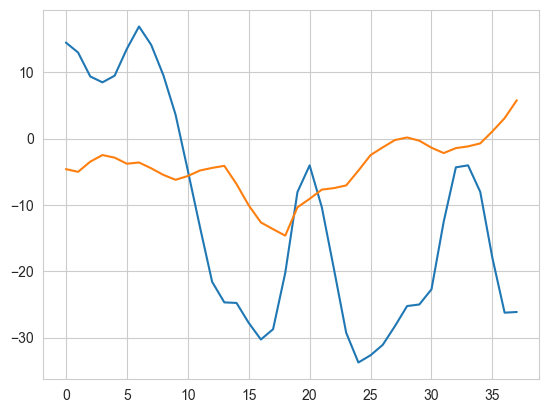

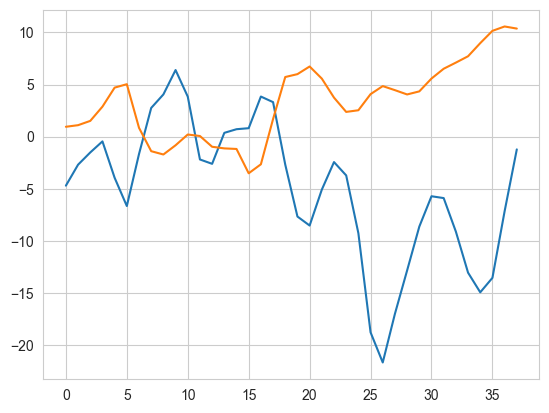

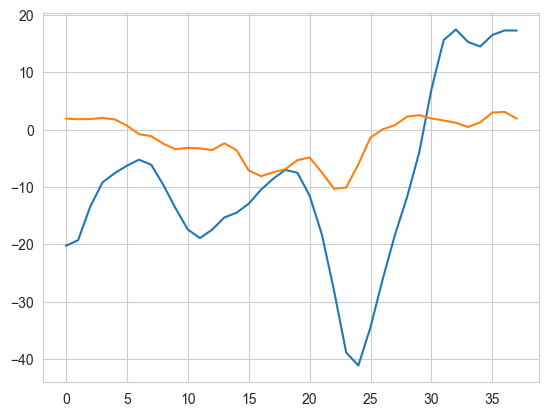

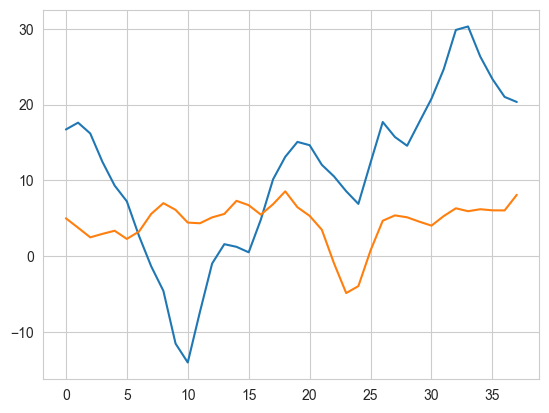

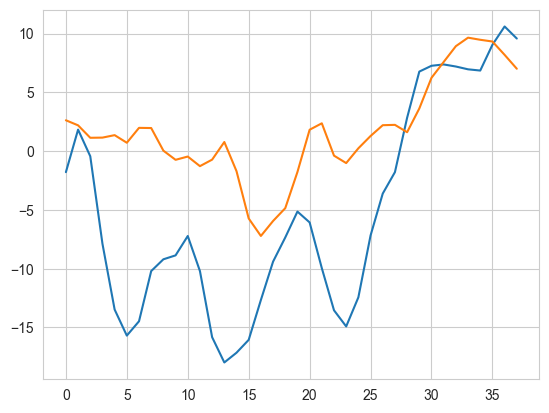

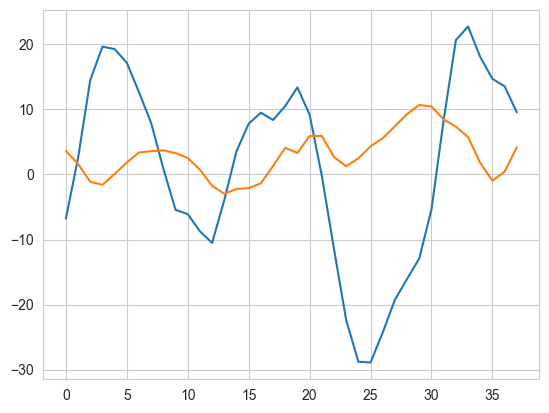

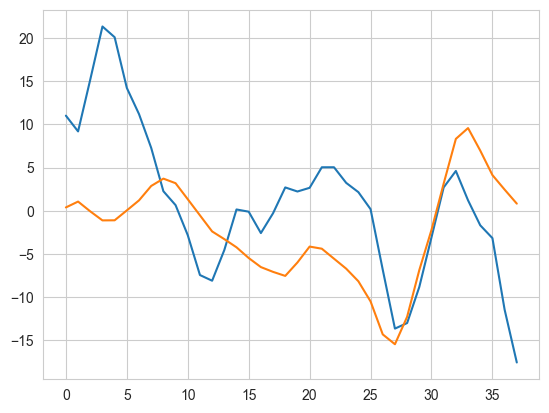

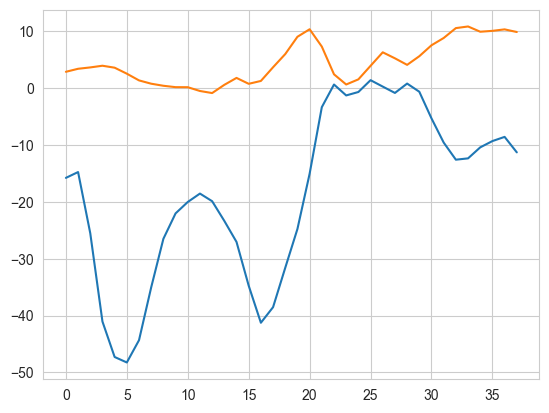

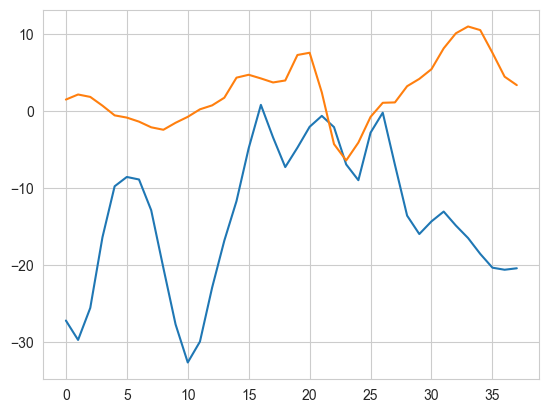

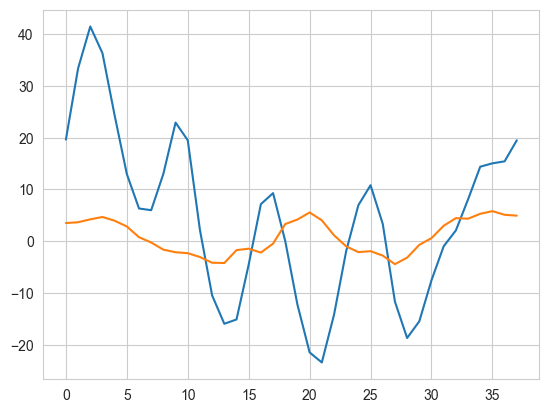

In [34]:
# test_original_cvs = res['Cz']['test_original'].to_numpy()
# test_predicted_cvs = res['Cz']['test_predicted'].to_numpy()
# # epochs: -0.2 to 1.58 ms -> 0 to 114
# t_min, t_max = -0.1, 0.5
# 
# t_min_tp = int((t_min - -0.2)*64)
# t_max_tp = int((t_max - -0.2)*64)
# 
# print(t_min_tp)
# print(t_max_tp)
# 
# for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
#     original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
#     predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]
#     
#     print(original_cropped.shape)
#     print(predicted_cropped.shape)
# 
#     original_cropped_ct = original_cropped.flatten()
#     predicted_cropped_ct = predicted_cropped.flatten()
# 
#     print(original_cropped_ct.shape)
#     print(predicted_cropped_ct.shape)
#     
#     plt.figure(i)
#     plt.plot(original_cropped[1])
#     plt.plot(predicted_cropped[1])
# 
#     r = np.corrcoef(original_cropped_ct, predicted_cropped_ct)[0, 1]
#     print(r)

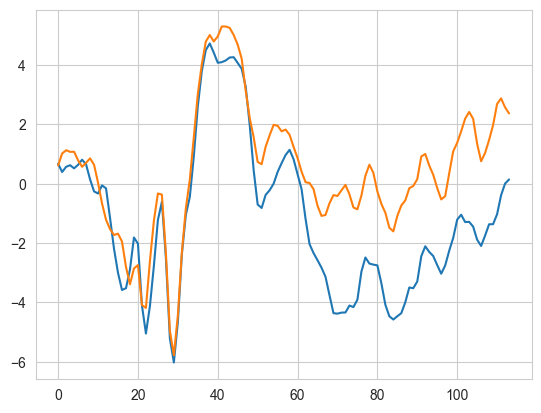

In [28]:
plt.plot(test_original_cvs.mean(axis=0).mean(axis=0))
plt.plot(test_predicted_cvs.mean(axis=0).mean(axis=0))

In [40]:
res = results_channels['Cz']
res

[[      channel     coefname  estimate eventname group stderror      time
  0           1     baseline  0.043226  baseline  None     None  0.000000
  1           1     baseline -0.027473  baseline  None     None  0.015625
  2           1     baseline -0.049124  baseline  None     None  0.031250
  3           1     baseline -0.038895  baseline  None     None  0.046875
  4           1     baseline -0.039280  baseline  None     None  0.062500
  ...       ...          ...       ...       ...   ...      ...       ...
  1119        1  (Intercept)  0.000000      test  None     None  1.488053
  1120        1  (Intercept)  0.000000      test  None     None  1.503540
  1121        1  (Intercept)  0.000000      test  None     None  1.519027
  1122        1  (Intercept)  0.000000      test  None     None  1.534513
  1123        1  (Intercept)  0.000000      test  None     None  1.550000
  
  [1124 rows x 7 columns],
  array([[  0.17346424,   0.20842445,   0.40326686, ..., -11.45579735,
          -

1. Average of a person

(198, 115)


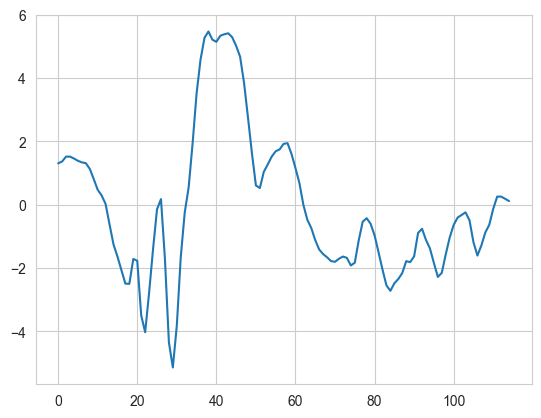

In [41]:
eeg_data_ = eeg_data.flatten().copy()
length = eeg_data_.shape[0]
trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
flattened_array = eeg_data_[:trimmed_length]  # Trim excess elements

epochs_eeg_data = flattened_array.reshape(-1, 115)
print(epochs_eeg_data.shape)

plt.plot(epochs_eeg_data.mean(axis=0))

2. Average of train and test splits 

In [42]:
# eeg_res_train = np.array(eeg_sets_channels['Cz'][0])
# eeg_res_test = np.array(eeg_sets_channels['Cz'][1])
# 
# mean_eeg_res_train = eeg_res_train.mean(axis=0).mean(axis=0)
# mean_eeg_res_test = eeg_res_test.mean(axis=0).mean(axis=0)
# 
# print(mean_eeg_res_train.shape)
# 
# plt.plot(mean_eeg_res_train, label='AVG of train splits signal')
# plt.plot(mean_eeg_res_test, label='AVG of test splits signal')
# plt.plot(epochs_eeg_data.mean(axis=0), label='AVG of whole signal')
# 
# plt.legend()

3. Predicted continuous to epochs

In [43]:
def slice_manually(signal, length_tp):
    continuous_signal = signal.flatten().copy()
    length = continuous_signal.shape[0]
    trimmed_length = (length // length_tp) * length_tp  # Find the largest multiple of 115
    flattened_array = continuous_signal[:trimmed_length]  # Trim excess elements
    
    epochs_eeg_data = flattened_array.reshape(-1, length_tp)
    
    return epochs_eeg_data

(20, 1, 11170)
(20, 1, 11284)
(97, 114)
(98, 114)


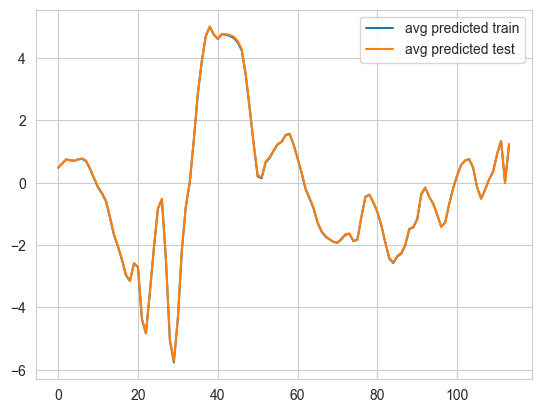

In [44]:
predicted_train = []
predicted_test = []
for i in range(0,20):
    predicted_train.append(res[i][1])
    predicted_test.append(res[i][2])

print(np.array(predicted_train).shape)
print(np.array(predicted_test).shape)

predicted_train = np.array(predicted_train)
predicted_test = np.array(predicted_test)

epochs_predicted_train = slice_manually(predicted_train.mean(0), 114)
epochs_predicted_test = slice_manually(predicted_test.mean(0), 114)

print(epochs_predicted_train.shape)
print(epochs_predicted_test.shape)

plt.plot(epochs_predicted_train.mean(axis=0), label = 'avg predicted train')
plt.plot(epochs_predicted_test.mean(axis=0), label = 'avg predicted test')

plt.legend()

4. Predicted train vs test by 

In [45]:
# # method
# evoked_from_continuous = unfold_model.evoked_from_raw(continuous_train, channel_events_train_df, event='go')
# plt.plot(evoked_from_continuous, label = 'continuous to method')
# 
# epochs_from_continuous = unfold_model.epochs_from_raw(continuous_train, channel_events_train_df, start_tp=-13, stop_tp=101)
# print(epochs_from_continuous.shape)
# plt.plot(epochs_from_continuous.mean(axis=0), label = 'continuous to method epochs')
# 
# 
# # manual
# eeg_data_ = continuous_train.flatten().copy()
# length = eeg_data_.shape[0]
# trimmed_length = (length // 114) * 114  # Find the largest multiple of 115
# flattened_array = eeg_data_[:trimmed_length]  # Trim excess elements
# 
# epochs_eeg_data = flattened_array.reshape(-1, 114)
# 
# plt.plot(epochs_eeg_data.mean(axis=0), label = 'manual slicing')
# 
# plt.legend()


In [46]:
# channel_events_train_df

In [47]:
# idx = 0
# 
# display(results_channels['Fp1'][idx][0])
# pred_train_f_0 = results_channels['Fp1'][idx][1]
# pred_test_f_0 = results_channels['Fp1'][idx][2]

In [48]:
# eeg_data.shape

In [49]:
# print(pred_train_f_0.shape)
# print(pred_test_f_0.shape)
# 
# print(eeg_data.shape)

In [50]:
# flattened_array = pred_train_f_0.flatten()
# length = flattened_array.shape[0]
# trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
# flattened_array = flattened_array[:trimmed_length]  # Trim excess elements
# 
# reshaped_array_train = flattened_array.reshape(-1, 115)
# 
# flattened_array = pred_test_f_0.flatten()
# length = flattened_array.shape[0]
# trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
# flattened_array = flattened_array[:trimmed_length]  # Trim excess elements
# 
# reshaped_array_test = flattened_array.reshape(-1, 115)
# 
# original_data = raw.get_data(picks='Fp1').flatten()
# 
# flattened_array = original_data
# length = flattened_array.shape[0]
# trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
# flattened_array = flattened_array[:trimmed_length]  # Trim excess elements
# 
# reshaped_array_original = flattened_array.reshape(-1, 115) * 1000000


In [51]:
# reshaped_array_original.shape

In [52]:
# plt.plot(reshaped_array_train.mean(axis=0))
# plt.plot(reshaped_array_test.mean(axis=0))
# plt.plot(reshaped_array_original.mean(axis=0))

In [53]:
ev_predicted_test = []
ev_predicted_train = []
ev_original_test = []
ev_original_train = []

for i in range(0,20):
    fold_0_data_df = results_channels['Cz'][i][0]
    ev_predicted_test.append(fold_0_data_df[(fold_0_data_df['eventname'] == 'test') & (fold_0_data_df['coefname'] == 'predicted')]['estimate'].to_numpy())
    ev_original_test.append(fold_0_data_df[(fold_0_data_df['eventname'] == 'test') & (fold_0_data_df['coefname'] == 'original')]['estimate'].to_numpy())
    
    ev_predicted_train.append(fold_0_data_df[(fold_0_data_df['eventname'] == 'train') & (fold_0_data_df['coefname'] == 'predicted')]['estimate'].to_numpy())
    ev_original_train.append(fold_0_data_df[(fold_0_data_df['eventname'] == 'train') & (fold_0_data_df['coefname'] == 'original')]['estimate'].to_numpy())

ev_original_train = np.array(ev_original_train)
ev_predicted_test = np.array(ev_predicted_test)
ev_predicted_train = np.array(ev_predicted_train)
ev_original_test = np.array(ev_original_test)

In [54]:
# print(eeg_res_train.mean(axis=1).shape)
print(ev_original_train.shape)

(20, 114)


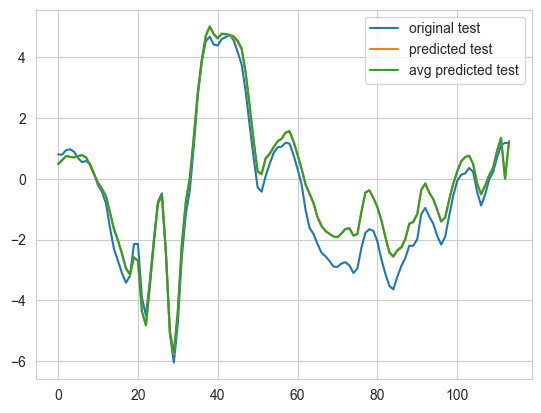

In [55]:
# plt.plot(ev_original_train.mean(axis=0), label = 'original train')
# plt.plot(ev_predicted_test.mean(axis=0), label = 'predicted train')
plt.plot(ev_original_test.mean(axis=0), label = 'original test')
plt.plot(ev_predicted_train.mean(axis=0), label = 'predicted test')

# plt.plot(epochs_predicted_train.mean(axis=0), label = 'avg predicted train')
plt.plot(epochs_predicted_test.mean(axis=0), label = 'avg predicted test')

eeg_data_ = eeg_data.flatten().copy()
length = eeg_data_.shape[0]
trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
flattened_array = eeg_data_[:trimmed_length]  # Trim excess elements

epochs_eeg_data = flattened_array.reshape(-1, 115)
# plt.plot(epochs_eeg_data.mean(axis=0), label='AVG of whole signal')

plt.legend()

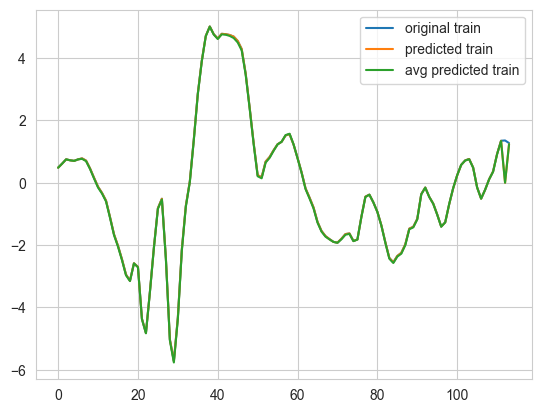

In [56]:
plt.plot(ev_original_train.mean(axis=0), label = 'original train')
plt.plot(ev_predicted_test.mean(axis=0), label = 'predicted train')
# plt.plot(ev_original_test.mean(axis=0), label = 'original test')
# plt.plot(ev_predicted_train.mean(axis=0), label = 'predicted test')

plt.plot(epochs_predicted_train.mean(axis=0), label = 'avg predicted train')
# plt.plot(epochs_predicted_test.mean(axis=0), label = 'avg predicted test')

eeg_data_ = eeg_data.flatten().copy()
length = eeg_data_.shape[0]
trimmed_length = (length // 115) * 115  # Find the largest multiple of 115
flattened_array = eeg_data_[:trimmed_length]  # Trim excess elements

epochs_eeg_data = flattened_array.reshape(-1, 115)
# plt.plot(epochs_eeg_data.mean(axis=0), label='AVG of whole signal')

plt.legend()

In [332]:
epochs_eeg_data.shape

(198, 115)

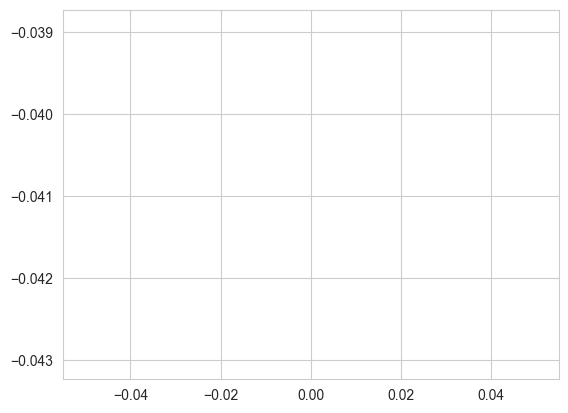

In [252]:
plt.plot(ev_original_train[0].mean(axis=0))

In [177]:
eeg_res_train.mean(axis=1).shape

(100,)

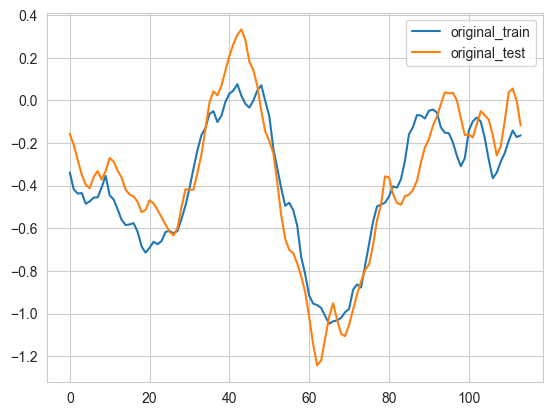

In [170]:
plt.plot(ev_original_train.mean(axis=0), label='original_train')
# plt.plot(ev_predicted_train.mean(axis=0), label='predicted_train')
plt.plot(ev_original_test.mean(axis=0), label='original_test')
# plt.plot(ev_predicted_test.mean(axis=0), label='predicted_test')

# plt.plot(mean_eeg_res_train, label='AVG of train splits signal')
# plt.plot(mean_eeg_res_test, label='AVG of test splits signal')

plt.legend()

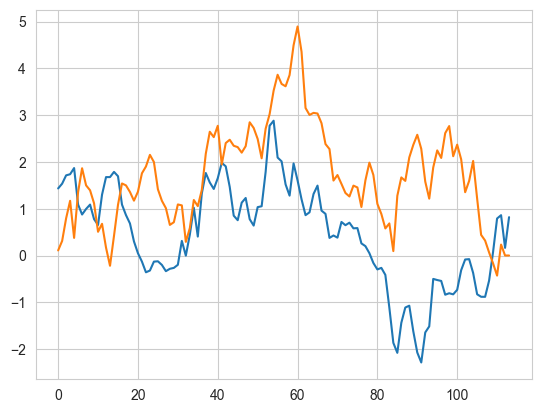

In [62]:
plt.plot(ev_original_test)
plt.plot(ev_predicted_test)

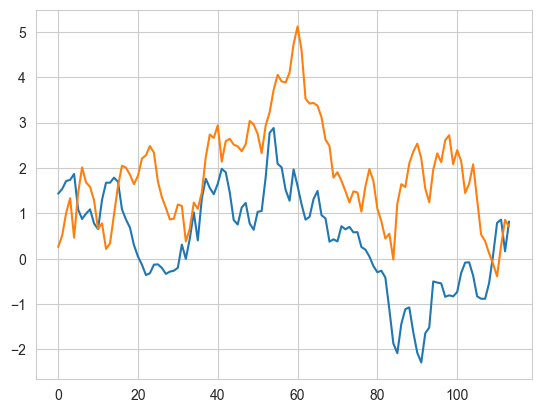

In [63]:
plt.plot(ev_original_test)
plt.plot(ev_original_train)

In [54]:
def create_events_cv(events_df, indices):
    events_split = []
    for i, data_index in enumerate(indices):
        trial_events_df = events_df.iloc[i].copy()
        offset = i*115
        trial_events_df['latency'] = trial_events_df['latency'].apply(lambda x: x+offset)
        events_split.append(trial_events_df)

    events_split_df = pd.concat(events_split, ignore_index=True)
    
    return events_split_df

In [62]:
events_split_ = create_events_cv(data_df['event_df'], train_index)
events_split_

,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
0,5,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
1,4,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
2,6,6,19,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
3,7,7,35,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523
4,8,8,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,309,309,11077,0,31,Stimulus/ 3-R-B-NOSTOP-L,response/correct,response_nostop,NaN,correct,n-a,NaN,-18.755500,False,NaN,NaN,NaN,NaN,NaN,NaN
306,310,310,11168,0,4,Stimulus/ 3-B-STOP1-SE-R,go/stop/1/SE,go,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
307,311,310,11168,0,4,Stimulus/ 3-B-STOP1-SE-R,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
308,312,312,11175,0,48,Stimulus/ 3-STOP1-SE-R,stop/1/SE,stop,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN


In [61]:
data_df['event_df'].iloc[0]

,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
0,5,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
1,4,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
2,6,6,19,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
3,7,7,35,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523


In [49]:
events_train = []
for i, data_index in enumerate(train_index):
    trial_events_df = data_df.iloc[i]['event_df'].copy()
    offset = i*115
    print(offset)
    trial_events_df['latency'] = trial_events_df['latency'].apply(lambda x: x+offset)
    
    events_train.append(trial_events_df)
    
print(len(events_train))
events_train_df = pd.concat(events_train, ignore_index=True)

0
115
230
345
460
575
690
805
920
1035
1150
1265
1380
1495
1610
1725
1840
1955
2070
2185
2300
2415
2530
2645
2760
2875
2990
3105
3220
3335
3450
3565
3680
3795
3910
4025
4140
4255
4370
4485
4600
4715
4830
4945
5060
5175
5290
5405
5520
5635
5750
5865
5980
6095
6210
6325
6440
6555
6670
6785
6900
7015
7130
7245
7360
7475
7590
7705
7820
7935
8050
8165
8280
8395
8510
8625
8740
8855
8970
9085
9200
9315
9430
9545
9660
9775
9890
10005
10120
10235
10350
10465
10580
10695
10810
10925
11040
11155
98


In [50]:
events_train_df

,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
0,5,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
1,4,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
2,6,6,19,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
3,7,7,35,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523
4,8,8,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,309,309,11077,0,31,Stimulus/ 3-R-B-NOSTOP-L,response/correct,response_nostop,NaN,correct,n-a,NaN,-18.755500,False,NaN,NaN,NaN,NaN,NaN,NaN
306,310,310,11168,0,4,Stimulus/ 3-B-STOP1-SE-R,go/stop/1/SE,go,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
307,311,310,11168,0,4,Stimulus/ 3-B-STOP1-SE-R,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
308,312,312,11175,0,48,Stimulus/ 3-STOP1-SE-R,stop/1/SE,stop,100.0,n-a,SE,NaN,73.826250,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN


In [51]:
data_df.iloc[0]['event_df']


,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
0,5,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
1,4,4,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
2,6,6,19,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
3,7,7,35,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523


In [52]:
data_df.iloc[1]['event_df']

,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
4,8,8,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
5,9,8,13,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
6,10,10,20,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
7,11,11,32,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,187.5,21.692167,False,-15.671642,3.05946,-0.479468,36.595395,3.40869,0.665293


In [53]:
data_df.iloc[2]['event_df']

,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
8,12,12,13,0,5,Stimulus/ 3-B-STOP1-SS-L,go/stop/1/SS,go,100.0,n-a,SS,NaN,5.099917,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
9,13,12,13,0,5,Stimulus/ 3-B-STOP1-SS-L,go/stop/1/SS,baseline,100.0,n-a,SS,NaN,5.099917,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
10,14,14,19,0,49,Stimulus/ 3-STOP1-SS-L,stop/1/SS,stop,100.0,n-a,SS,NaN,5.099917,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN


In [48]:
data_df.iloc[3]['event_df']


,level_0,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
11,15,16,13,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,go,NaN,n-a,n-a,NaN,-5.514833,False,NaN,NaN,NaN,NaN,NaN,NaN
12,16,16,13,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,baseline,NaN,n-a,n-a,NaN,-5.514833,False,NaN,NaN,NaN,NaN,NaN,NaN
13,17,17,44,0,31,Stimulus/ 3-R-B-NOSTOP-L,response/correct,response_nostop,NaN,correct,n-a,NaN,-5.514833,False,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
train_index

In [16]:
channel_events_df

,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
4,4,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
5,4,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
6,6,134,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,NaN,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
7,7,150,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523
8,8,243,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,NaN,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,626,22553,0,5,Stimulus/ 3-B-STOP1-SS-L,go/stop/1/SS,go,100.0,n-a,SS,NaN,-5.885500,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
628,628,22559,0,49,Stimulus/ 3-STOP1-SS-L,stop/1/SS,stop,100.0,n-a,SS,NaN,-5.885500,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
629,629,22668,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,go,NaN,n-a,n-a,NaN,-21.871833,False,NaN,NaN,NaN,NaN,NaN,NaN
630,629,22668,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,baseline,NaN,n-a,n-a,NaN,-21.871833,False,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
epoched_raw

array([[-6.0574e+01, -5.8948e+01, -5.3231e+01, ...,  7.8060e+00,
         1.8001e+01,  2.4303e+01],
       [ 2.8736e+01,  2.8675e+01,  2.6794e+01, ...,  4.0570e+00,
         7.1100e+00,  7.8110e+00],
       [ 4.6890e+00,  3.6470e+00,  3.6370e+00, ..., -2.2920e+00,
        -3.1050e+00, -4.4750e+00],
       ...,
       [-1.4972e+01, -9.6340e+00,  5.9000e-02, ...,  5.3440e+00,
         8.9780e+00,  6.7510e+00],
       [-9.5590e+00, -1.3431e+01, -1.4830e+01, ..., -1.1080e+01,
        -8.3560e+00, -6.1620e+00],
       [-5.5590e+00, -8.6180e+00, -1.7304e+01, ...,  2.5150e+01,
         2.4457e+01,  2.4643e+01]])

In [35]:
dfs

[   level_0  index  latency  duration  id                       event  \
 0        5      4        0         0   3    Stimulus/ 3-B-STOP1-SE-L   
 1        4      4        0         0   3    Stimulus/ 3-B-STOP1-SE-L   
 2        6      6        6         0  47      Stimulus/ 3-STOP1-SE-L   
 3        7      7       22         0  33  Stimulus/ 3-R-B-STOP1-SE-L   
 
           event_general           type    ssd response_type stop_type    sri  \
 0          go/stop/1/SE             go  100.0           n-a        SE    NaN   
 1          go/stop/1/SE       baseline  100.0           n-a        SE    NaN   
 2             stop/1/SE           stop  100.0           n-a        SE    NaN   
 3  response/incorrect/1  response_stop  100.0     incorrect       n-a  250.0   
 
     baseline    bad  ssd_center  ssd_standardized  ssd_normalized  sri_center  \
 0 -45.443583  False  -15.671642           3.05946       -0.479468         NaN   
 1 -45.443583  False  -15.671642           3.05946       -0.47

In [38]:
len(go_indices)

198